# **Experiment Notebook**



In [288]:
# Do not modify this code
!pip install -q utstd

from utstd.ipyrenders import *

In [289]:
# Do not modify this code
import warnings
warnings.simplefilter(action='ignore')

## 0. Import Packages

In [290]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pathlib
import joblib
import os

---
## A. Project Description


In [291]:
# <Student to fill this section>
student_name = "Parth Tiwari"
student_id = "25506751"
group_id = "group30"

In [292]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [293]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

In [294]:
# Do not modify this code
print_tile(size="h1", key='group_id', value=group_id)

---
## B. Business Understanding

In [295]:
# <Student to fill this section>
business_use_case_description = """
The objective is to give investors the past price and the forecasts of the high price of XRP in the coming day to help them make investment decisions regarding cryptocurrencies."""

In [296]:
# Do not modify this code
print_tile(size="h3", key='business_use_case_description', value=business_use_case_description)

In [297]:
# <Student to fill this section>
business_objectives = """
Deliberately correct forecasts may assist users to predict high prices, which can assist in buy/sell decision-making. Failure to make forecasts correctly can result in losses."""

In [298]:
# Do not modify this code
print_tile(size="h3", key='business_objectives', value=business_objectives)

In [299]:
# <Student to fill this section>
stakeholders_expectations_explanations = """
Cryptocurrency investors will utilize results. The trading strategies and profits/losses are affected by predictions.
"""

In [300]:
# Do not modify this code
print_tile(size="h3", key='stakeholders_expectations_explanations', value=stakeholders_expectations_explanations)

---
## C. Data Understanding

### C.1   Load Datasets


In [301]:
files = [
    "XRP_01_01_2015-01_01_2016_historical_data_coinmarketcap.csv",
    "XRP_01_01_2016-01_01_2017_historical_data_coinmarketcap.csv",
    "XRP_01_01_2017-01_01_2018_historical_data_coinmarketcap.csv",
    "XRP_01_01_2018-01_01_2019_historical_data_coinmarketcap.csv",
    "XRP_01_01_2019-01_01_2020_historical_data_coinmarketcap.csv",
    "XRP_01_01_2020-01_01_2021_historical_data_coinmarketcap.csv",
    "XRP_01_01_2021-01_01_2022_historical_data_coinmarketcap.csv",
    "XRP_01_01_2022-01_01_2023_historical_data_coinmarketcap.csv",
    "XRP_01_01_2023-01_01_2024_historical_data_coinmarketcap.csv",
    "XRP_01_01_2024-01_01_2025_historical_data_coinmarketcap.csv"
]

!pip install -i https://test.pypi.org/simple/ my_krml_25506751==2025.0.8.0

from my_krml_25506751.data.sets import load_data

df_list = []
for file in files:
    try:
        df_temp = load_data(file)
        if len(df_temp.columns) == 1:
            df_temp = pd.read_csv(file, sep=';', parse_dates=['timeOpen', 'timeClose', 'timeHigh', 'timeLow', 'timestamp'])
        df_list.append(df_temp)
    except pd.errors.EmptyDataError:
        print(f"File {file} is empty, skipping.")

df = pd.concat(df_list, ignore_index=True)

df = df.sort_values(by='timeOpen').reset_index(drop=True)

Looking in indexes: https://test.pypi.org/simple/


In [302]:
df.columns

Index(['timeOpen', 'timeClose', 'timeHigh', 'timeLow', 'name', 'open', 'high',
       'low', 'close', 'volume', 'marketCap', 'timestamp'],
      dtype='object')

In [303]:
# Display basic info
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3653 entries, 0 to 3652
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype              
---  ------     --------------  -----              
 0   timeOpen   3653 non-null   datetime64[ns, UTC]
 1   timeClose  3653 non-null   datetime64[ns, UTC]
 2   timeHigh   3653 non-null   datetime64[ns, UTC]
 3   timeLow    3653 non-null   datetime64[ns, UTC]
 4   name       3653 non-null   int64              
 5   open       3653 non-null   float64            
 6   high       3653 non-null   float64            
 7   low        3653 non-null   float64            
 8   close      3653 non-null   float64            
 9   volume     3653 non-null   float64            
 10  marketCap  3653 non-null   float64            
 11  timestamp  3653 non-null   datetime64[ns, UTC]
dtypes: datetime64[ns, UTC](5), float64(6), int64(1)
memory usage: 342.6 KB
None


In [304]:
print(df.head())

                   timeOpen                        timeClose  \
0 2015-01-01 00:00:00+00:00 2015-01-01 23:59:59.999000+00:00   
1 2015-01-02 00:00:00+00:00 2015-01-02 23:59:59.999000+00:00   
2 2015-01-03 00:00:00+00:00 2015-01-03 23:59:59.999000+00:00   
3 2015-01-04 00:00:00+00:00 2015-01-04 23:59:59.999000+00:00   
4 2015-01-05 00:00:00+00:00 2015-01-05 23:59:59.999000+00:00   

                   timeHigh                   timeLow  name      open  \
0 2015-01-01 00:04:04+00:00 2015-01-01 05:24:04+00:00  2781  0.024455   
1 2015-01-02 03:09:04+00:00 2015-01-02 23:09:05+00:00  2781  0.024377   
2 2015-01-03 00:29:04+00:00 2015-01-03 23:59:04+00:00  2781  0.024297   
3 2015-01-04 00:49:04+00:00 2015-01-04 23:04:04+00:00  2781  0.022100   
4 2015-01-05 23:59:04+00:00 2015-01-05 00:09:04+00:00  2781  0.018943   

       high       low     close     volume     marketCap  \
0  0.024455  0.024205  0.024390   399022.0  7.555584e+08   
1  0.024423  0.024309  0.024318   459956.0  7.533403e+08

In [305]:
df.describe()

,name,open,high,low,close,volume,marketCap
count,3653.0,3653.000000,3653.000000,3653.000000,3653.000000,3.653000e+03,3.653000e+03
mean,2781.0,0.407919,0.424349,0.390961,0.408496,1.788268e+09,1.925848e+10
std,0.0,0.392145,0.417023,0.368030,0.393119,3.360717e+09,1.935655e+10
min,2781.0,0.004091,0.004189,0.004041,0.004090,2.481880e+04,1.371705e+08
25%,2781.0,0.177582,0.182599,0.171549,0.177882,8.840800e+07,7.083526e+09
50%,2781.0,0.341807,0.353079,0.330305,0.342082,9.766888e+08,1.525609e+10
75%,2781.0,0.548021,0.567293,0.529788,0.548045,1.889112e+09,2.824906e+10
max,2781.0,3.363570,3.841940,3.117340,3.377810,5.172338e+10,1.548332e+11


### C.2 Define Target variable

In [306]:
# <Student to fill this section>
target_definition_explanations = """
The target variable is established as the high price of the following day (day +1) which is in line with the business objective to forecast the potential high prices to make investment decisions."""

In [307]:
# Do not modify this code
print_tile(size="h3", key='target_definition_explanations', value=target_definition_explanations)

### C.3 Create Target variable

In [308]:
df['target'] = df['high'].shift(-1)

In [309]:
df = df.dropna()

In [310]:
df[['timeOpen', 'high', 'target']].tail()

,timeOpen,high,target
3647,2024-12-26 00:00:00+00:00,2.311979,2.231316
3648,2024-12-27 00:00:00+00:00,2.231316,2.199492
3649,2024-12-28 00:00:00+00:00,2.199492,2.192813
3650,2024-12-29 00:00:00+00:00,2.192813,2.143189
3651,2024-12-30 00:00:00+00:00,2.143189,2.140974


### C.4 Explore Target variable

In [311]:
print("Summary Statistics for Target Variable (Next-Day High Price):")
print(df['target'].describe())

Summary Statistics for Target Variable (Next-Day High Price):
count    3652.000000
mean        0.424459
std         0.417028
min         0.004189
25%         0.182623
50%         0.353194
75%         0.567295
max         3.841940
Name: target, dtype: float64


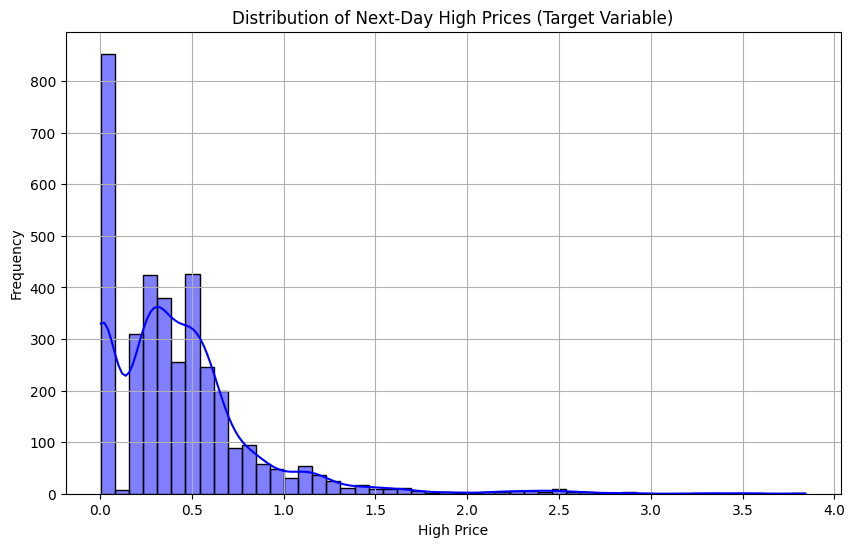

In [312]:
plt.figure(figsize=(10, 6))
sns.histplot(df['target'], bins=50, kde=True, color='blue')
plt.title('Distribution of Next-Day High Prices (Target Variable)')
plt.xlabel('High Price')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

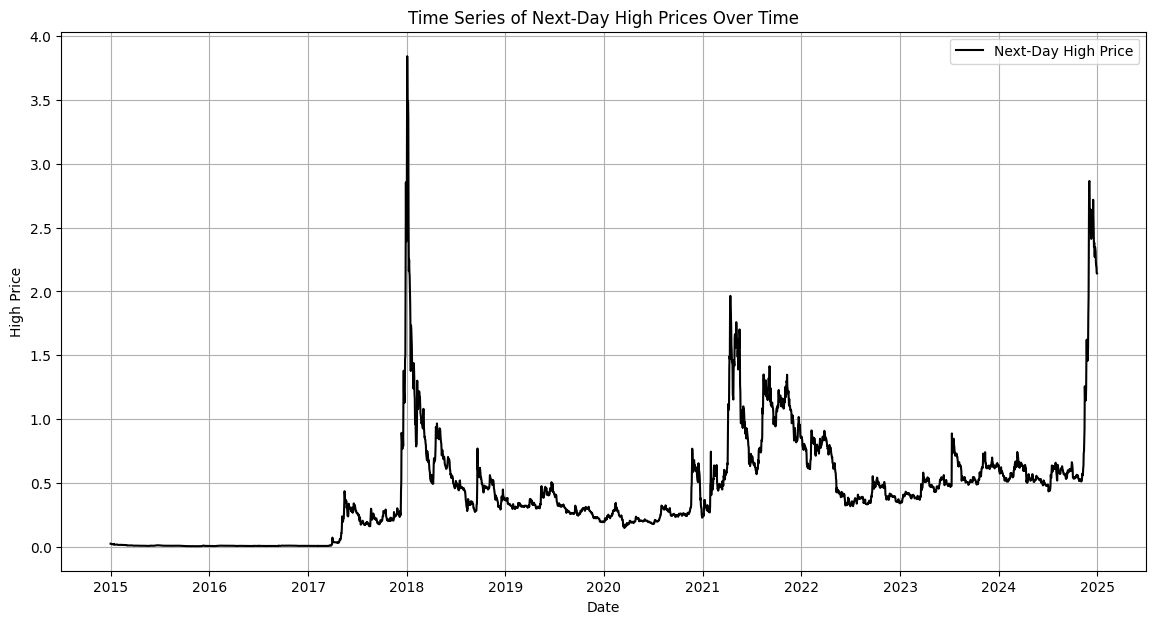

In [313]:
plt.figure(figsize=(14, 7))
plt.plot(df['timeOpen'], df['target'], color='black', label='Next-Day High Price')
plt.title('Time Series of Next-Day High Prices Over Time')
plt.xlabel('Date')
plt.ylabel('High Price')
plt.legend()
plt.grid(True)
plt.show()


Correlation Matrix for Target and Key Features:
target    1.000000
close     0.995725
high      0.993403
low       0.988136
open      0.986956
volume    0.569546
Name: target, dtype: float64


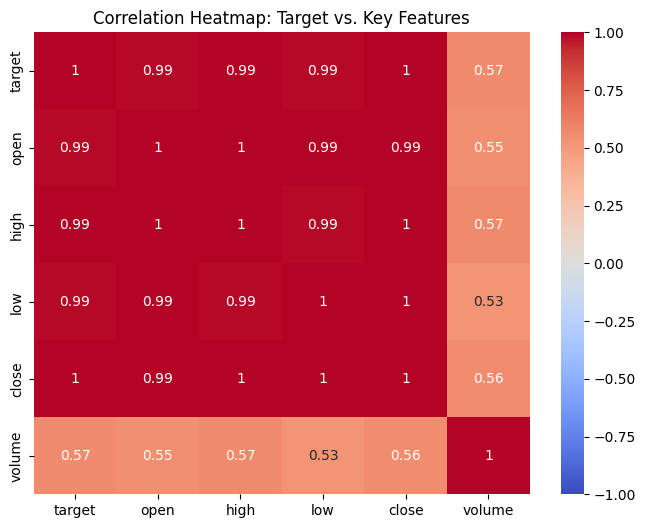

In [314]:
correlation_matrix = df[['target', 'open', 'high', 'low', 'close', 'volume']].corr()
print("\nCorrelation Matrix for Target and Key Features:")
print(correlation_matrix['target'].sort_values(ascending=False))

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap: Target vs. Key Features')
plt.show()

In [315]:
# <Student to fill this section>
target_distribution_explanations = """
The skewness of the next-day high is positive (mean of 0.42> median of 0.35), volatility of 0.4 2), exceeds 3652 days. All values fall between range 0.004-3.84 which is growth stages; good when analyzing long-term trend."""

In [316]:
# Do not modify this code
print_tile(size="h3", key='target_distribution_explanations', value=target_distribution_explanations)

### C.5 Explore Feature of Interest: Volume

In [317]:
print("Summary Statistics for Feature of Interest (Volume):")
print(df['volume'].describe())

Summary Statistics for Feature of Interest (Volume):
count    3.652000e+03
mean     1.787464e+09
std      3.360826e+09
min      2.481880e+04
25%      8.840548e+07
50%      9.760959e+08
75%      1.888135e+09
max      5.172338e+10
Name: volume, dtype: float64


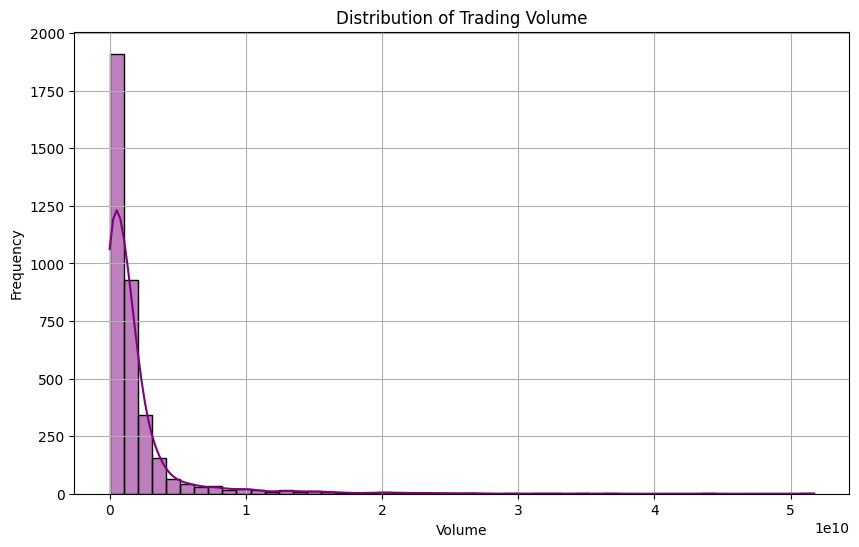

In [318]:
plt.figure(figsize=(10, 6))
sns.histplot(df['volume'], bins=50, kde=True, color='purple')
plt.title('Distribution of Trading Volume')
plt.xlabel('Volume')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

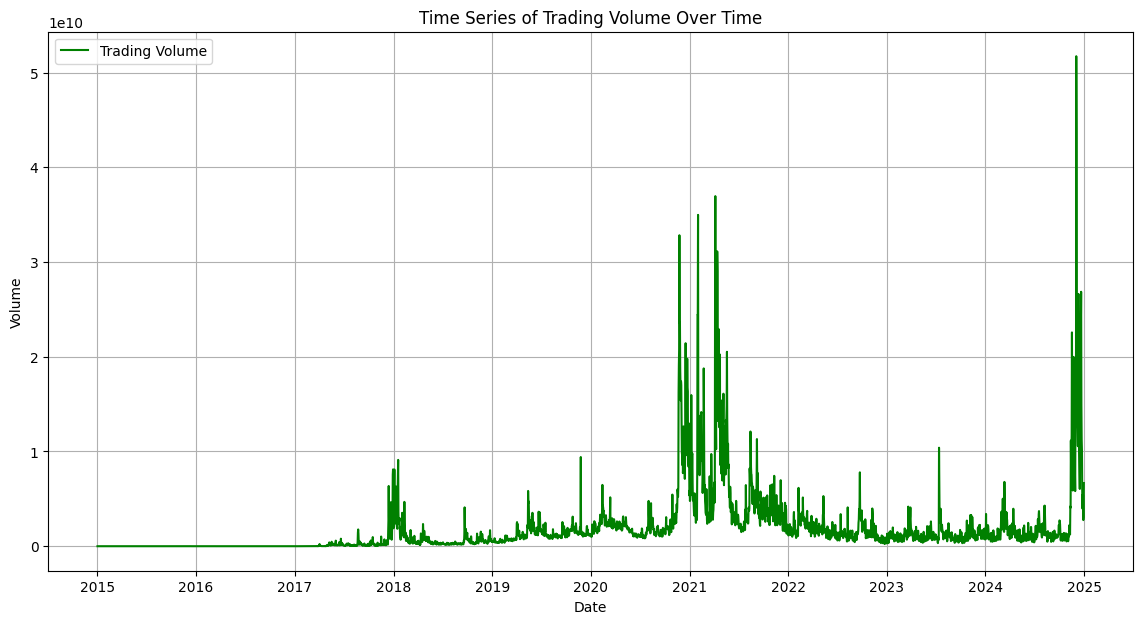

In [319]:
plt.figure(figsize=(14, 7))
plt.plot(df['timeOpen'], df['volume'], color='green', label='Trading Volume')
plt.title('Time Series of Trading Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.legend()
plt.grid(True)
plt.show()

In [320]:
# <Student to fill this section>
feature_1_insights = """
The skewness of the trading volume is large (mean 1.79B > median 976M), volatility is extreme (std 3.36B). Full range of 25K to 51.7B in 3652 days represents market growth and peaks of bull runs."""

In [321]:
# Do not modify this code
print_tile(size="h3", key='feature_1_insights', value=feature_1_insights)

### C.6 Explore Feature of Interest: Close

In [322]:
print("Summary Statistics for Feature of Interest (Close):")
print(df['close'].describe())

Summary Statistics for Feature of Interest (Close):
count    3652.000000
mean        0.408038
std         0.392199
min         0.004090
25%         0.177835
50%         0.341855
75%         0.548027
max         3.377810
Name: close, dtype: float64


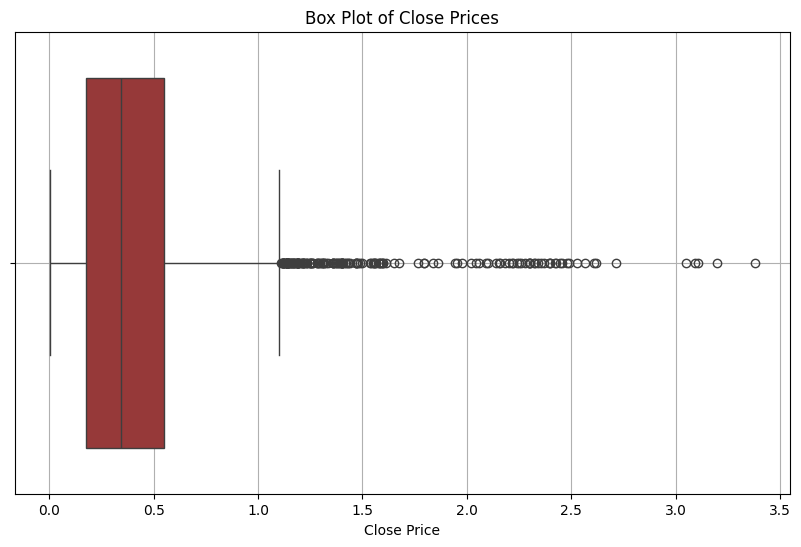

In [323]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['close'], color='brown')
plt.title('Box Plot of Close Prices')
plt.xlabel('Close Price')
plt.grid(True)
plt.show()


Correlation Matrix for Close and Key Features:
close     1.000000
high      0.996802
low       0.995771
target    0.995725
open      0.993358
volume    0.559854
Name: close, dtype: float64


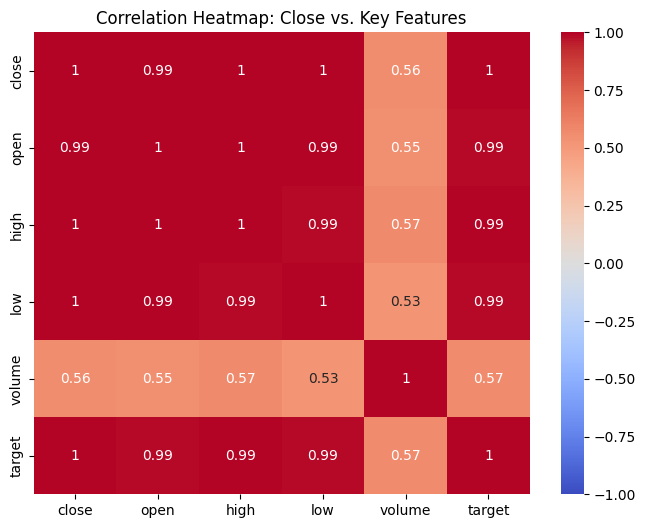

In [324]:
correlation_matrix = df[['close', 'open', 'high', 'low', 'volume', 'target']].corr()
print("\nCorrelation Matrix for Close and Key Features:")
print(correlation_matrix['close'].sort_values(ascending=False))

# Heatmap for visualization of correlations
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap: Close vs. Key Features')
plt.show()

In [325]:
# <Student to fill this section>
feature_2_insights = """
There is a positive skew of close prices (mean 0.41 greater than the median 0.34), high volatility (std 0.39). Within 3652 days, the range is 0.004-3.38, which represents the bull peaks and growth in general."""

In [326]:
# Do not modify this code
print_tile(size="h3", key='feature_2_insights', value=feature_2_insights)

### C.6 Explore Feature of Interest: Open


In [327]:
print("Summary Statistics for Feature of Interest (Open):")
print(df['open'].describe())

Summary Statistics for Feature of Interest (Open):
count    3652.000000
mean        0.407468
std         0.391247
min         0.004091
25%         0.177569
50%         0.341703
75%         0.547995
max         3.363570
Name: open, dtype: float64


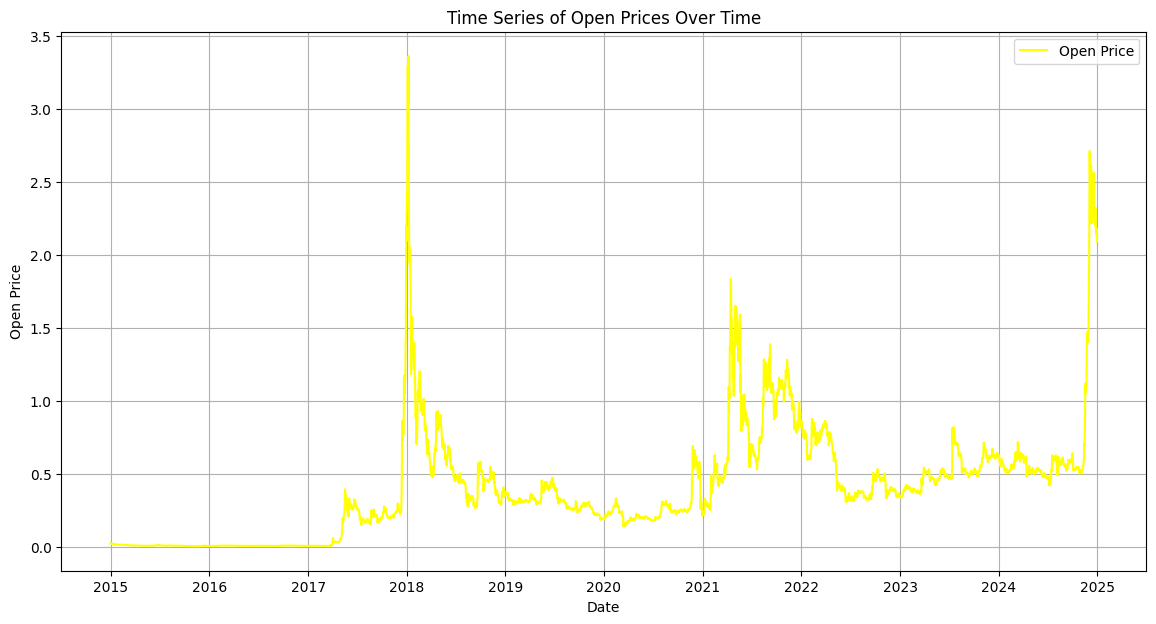

In [328]:
plt.figure(figsize=(14, 7))
plt.plot(df['timeOpen'], df['open'], color='yellow', label='Open Price')
plt.title('Time Series of Open Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Open Price')
plt.legend()
plt.grid(True)
plt.show()

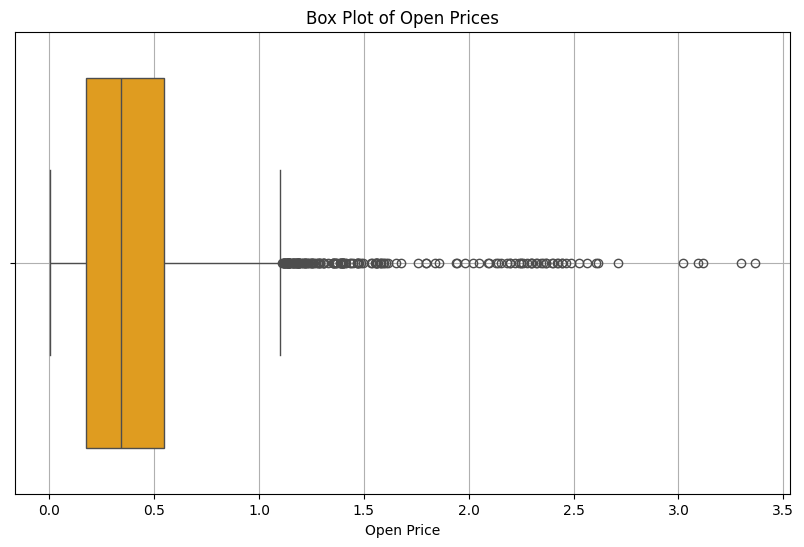

In [329]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['open'], color='orange')
plt.title('Box Plot of Open Prices')
plt.xlabel('Open Price')
plt.grid(True)
plt.show()

In [330]:
# <Student to fill this section>
feature_n_insights = """
Open prices were skewed positively (mean 0.41 greater than median 0.34), and highly volatile (std 0.39). PR -0.004336 across 3652 days, which reflects the growth and market trends in crypto."""

In [331]:
# Do not modify this code
print_tile(size="h3", key='feature_n_insights', value=feature_n_insights)

### C.7   Explore Feature of Interest Low

In [332]:
print("Summary Statistics for Feature of Interest (Low):")
print(df['low'].describe())

Summary Statistics for Feature of Interest (Low):
count    3652.000000
mean        0.390516
std         0.367098
min         0.004041
25%         0.171544
50%         0.329941
75%         0.529637
max         3.117340
Name: low, dtype: float64


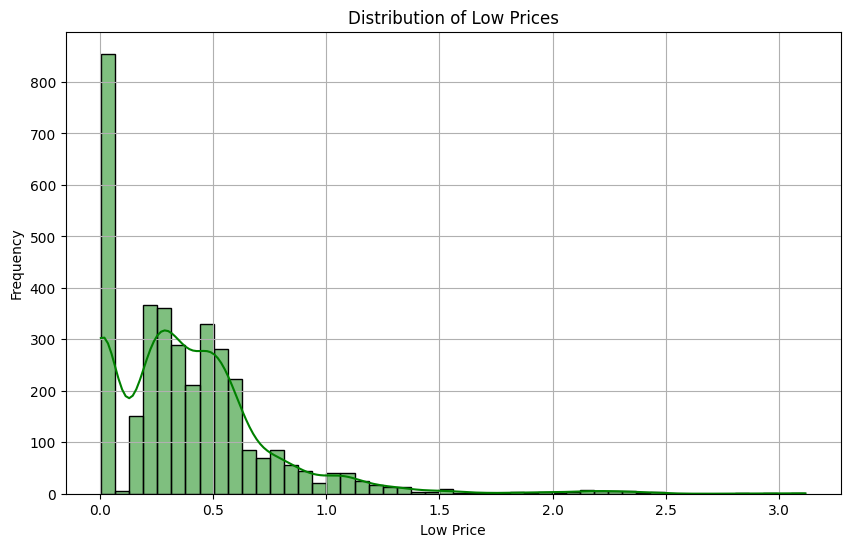

In [333]:
plt.figure(figsize=(10, 6))
sns.histplot(df['low'], bins=50, kde=True, color='green')
plt.title('Distribution of Low Prices')
plt.xlabel('Low Price')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


Correlation Matrix for Low and Key Features:
low       1.000000
close     0.995771
open      0.994665
high      0.991937
target    0.988136
volume    0.530330
Name: low, dtype: float64


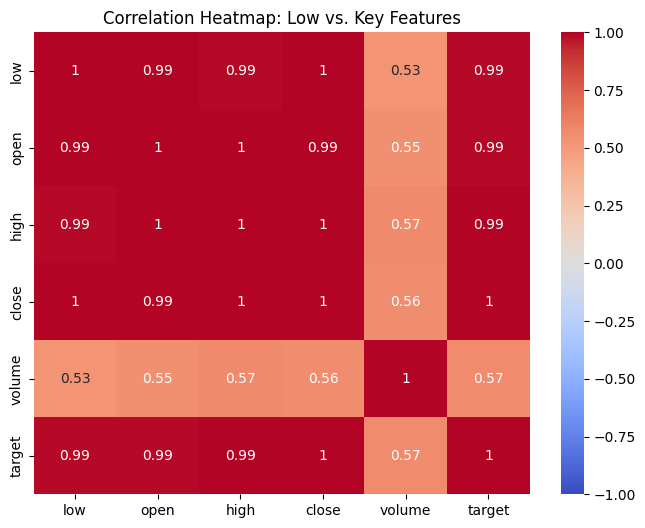

In [334]:
correlation_matrix = df[['low', 'open', 'high', 'close', 'volume', 'target']].corr()
print("\nCorrelation Matrix for Low and Key Features:")
print(correlation_matrix['low'].sort_values(ascending=False))

# Heatmap for visualization of correlations
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap: Low vs. Key Features')
plt.show()

In [335]:
feature_distribution_explanations = """
Low prices (mean skewness of 0.39, median skewness of 0.33) were skewed positively, and volatility (sd 0.37) high. The range of $0.004-3.12 during 3652 days indicating the market lows and recovery trends."""

In [336]:
# Do not modify this code
print_tile(size="h3", key='feature_distribution_explanations', value=feature_distribution_explanations)

---
## D. Feature Selection


### D.1 Approach: Select features with |corr| > 0.8


In [337]:
corr_matrix = df[['open', 'high', 'low', 'close', 'volume', 'marketCap', 'target']].corr()

corr_with_target = corr_matrix['target'].abs().sort_values(ascending=False)
print("Correlations with Target:\n", corr_with_target)

selected_features = corr_with_target[(corr_with_target > 0.8) & (corr_with_target.index != 'target')].index.tolist()
print("\nSelected Features:", selected_features)

X = df[selected_features]
y = df['target']

Correlations with Target:
 target       1.000000
close        0.995725
high         0.993403
low          0.988136
open         0.986956
marketCap    0.974244
volume       0.569546
Name: target, dtype: float64

Selected Features: ['close', 'high', 'low', 'open', 'marketCap']


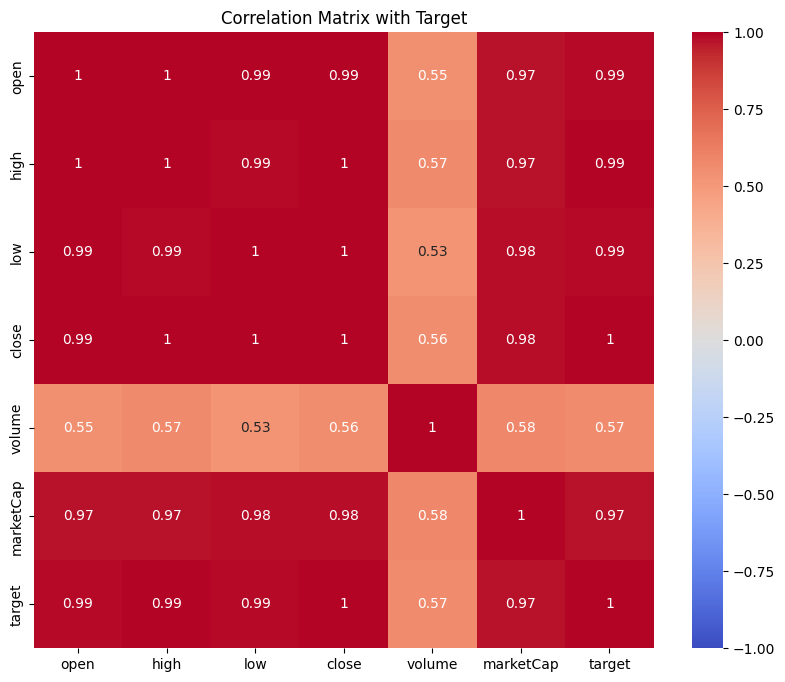

In [338]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix with Target')
plt.show()

In [339]:
# <Student to fill this section>
feature_selection_1_insights = """
Target had a high level of correlation with prices (close 0.996, high 0.993, low 0.988, open 0.987), marketCap (0.974), which means that it predicts well. Volume (0.57) that was picked to gain momentum insights."""

In [340]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_1_insights', value=feature_selection_1_insights)

### D.2 Approach: variance-based feature selection


Feature Variances:
 marketCap    3.719284e+20
volume       1.129206e+19
high         1.731011e-01
close        1.537776e-01
open         1.530326e-01
low          1.347241e-01
dtype: float64

Variance-Selected Features: ['marketCap', 'volume', 'high', 'close', 'open', 'low']


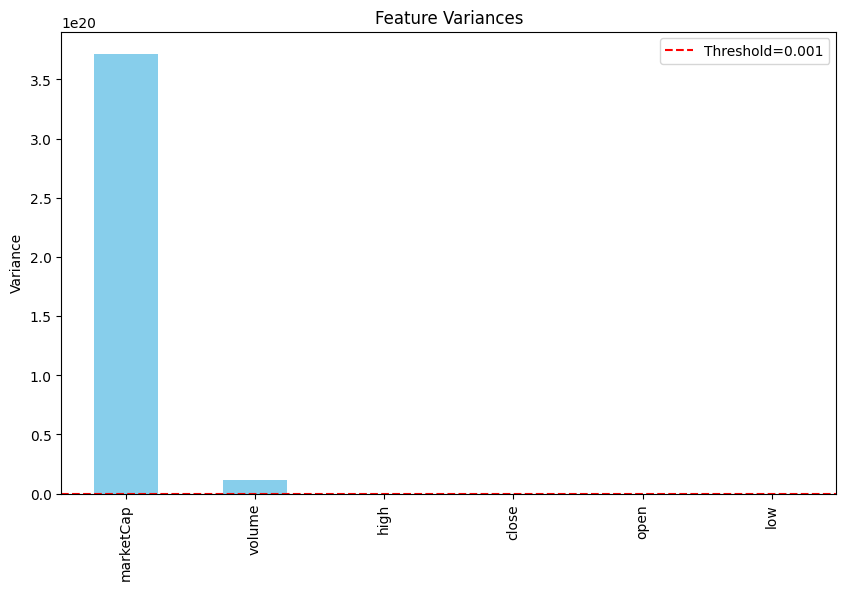


Combined Selected Features: ['open', 'marketCap', 'close', 'low', 'volume', 'high']


In [341]:
existing_features = ['open', 'high', 'low', 'close', 'volume', 'marketCap']
X = df[existing_features].values
y = df['target']

variances = np.var(X, axis=0)
variance_series = pd.Series(variances, index=existing_features).sort_values(ascending=False)
print("Feature Variances:\n", variance_series)

threshold = 0.001
selected_features_var = variance_series[variance_series > threshold].index.tolist()
print("\nVariance-Selected Features:", selected_features_var)

X_df = df[selected_features_var]

plt.figure(figsize=(10, 6))
variance_series.plot(kind='bar', color='skyblue')
plt.title('Feature Variances')
plt.ylabel('Variance')
plt.axhline(y=threshold, color='red', linestyle='--', label=f'Threshold={threshold}')
plt.legend()
plt.show()

final_features = list(set(selected_features + selected_features_var))
print("\nCombined Selected Features:", final_features)
X = df[final_features]

In [342]:
# <Student to fill this section>
feature_selection_2_insights = """
MarketCap (3.72e20) and volume (1.13e19) have high variance, so there will be rich information to be used to predict. Price characteristics (~0.13-0.17) were chosen because it was already over threshold, thus volatility is capturing to model well."""

In [343]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_2_insights', value=feature_selection_2_insights)

## D.3 Final Selection of Features

Final Selected Features: ['open', 'marketCap', 'close', 'low', 'high']

Correlations of Final Features with Target:
 target       1.000000
close        0.995725
high         0.993403
low          0.988136
open         0.986956
marketCap    0.974244
Name: target, dtype: float64


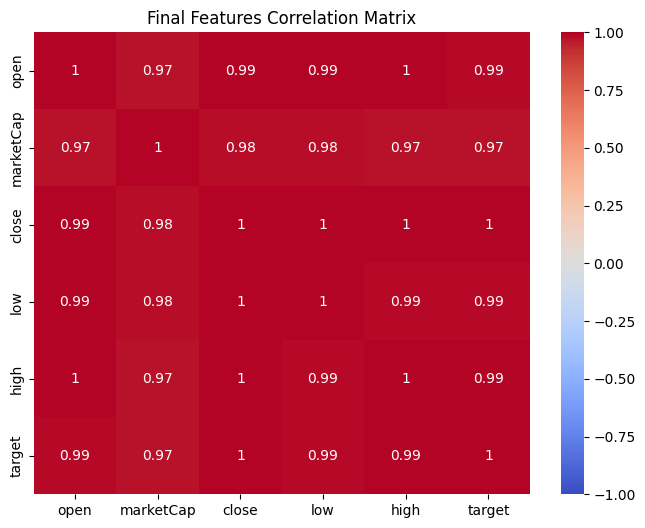

In [344]:
features_from_d1 = ['close', 'high', 'low', 'open', 'marketCap']  # From D.1
features_from_d2 = ['marketCap', 'volume', 'high', 'close', 'open', 'low']  # From D.2

final_features = list(set(features_from_d1 + features_from_d2))
if 'volume' in final_features:
    final_features.remove('volume')

print("Final Selected Features:", final_features)

X = df[final_features]
y = df['target']

corr_final = df[final_features + ['target']].corr()['target'].sort_values(ascending=False)
print("\nCorrelations of Final Features with Target:\n", corr_final)

plt.figure(figsize=(8, 6))
sns.heatmap(df[final_features + ['target']].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Final Features Correlation Matrix')
plt.show()

In [345]:
# <Student to fill this section>
feature_selection_explanations = """
Final features (open, marketCap, close, low, high) selected for high correlations (>0.97) with target, emphasizing price and valuation signals. Excludes volume (0.57 corr) to focus on strong linear predictors for XRP high price forecasting."""

In [346]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_explanations', value=feature_selection_explanations)

---
## E. Data Preparation

### E.1 Data Transformation: Handle Outliers

In [347]:
def clip_outliers(series, factor=1.5):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - factor * IQR
    upper_bound = Q3 + factor * IQR
    return series.clip(lower_bound, upper_bound)

numerical_cols = final_features + ['target', 'volume']
for col in numerical_cols:
    if col in df.columns:
        df[col] = clip_outliers(df[col])

print("Data after outlier clipping:")
print(df[numerical_cols].describe())

Data after outlier clipping:
              open     marketCap        close          low         high  \
count  3652.000000  3.652000e+03  3652.000000  3652.000000  3652.000000   
mean      0.383651  1.830355e+10     0.383934     0.370026     0.396599   
std       0.307062  1.546575e+10     0.307222     0.294544     0.318759   
min       0.004091  1.371705e+08     0.004090     0.004041     0.004189   
25%       0.177569  7.078205e+09     0.177835     0.171544     0.182524   
50%       0.341703  1.522508e+10     0.341855     0.329941     0.352951   
75%       0.547995  2.824389e+10     0.548027     0.529637     0.566905   
max       1.103634  5.999241e+10     1.103316     1.066778     1.143476   

            target        volume  
count  3652.000000  3.652000e+03  
mean      0.396949  1.308604e+09  
std       0.319040  1.377083e+09  
min       0.004189  2.481880e+04  
25%       0.182623  8.840548e+07  
50%       0.353194  9.760959e+08  
75%       0.567295  1.888135e+09  
max       1.144

In [348]:
# <Student to fill this section>
data_cleaning_1_explanations = """
Outliers removed through IQR, which lower the max prices (~1.1) and the volume (~4.6B) to smooth outliers in the dynamic XRP data to train stable models without eliminating important trends."""

In [349]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_1_explanations', value=data_cleaning_1_explanations)

### E.2 Data Transformation: Normalization/Scaling

In [350]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(df[final_features]), columns=final_features, index=df.index)

y_scaled = scaler.fit_transform(df[['target']]).ravel()

X = X_scaled

In [351]:
# <Student to fill this section>
data_cleaning_2_explanations = """
Features standardized (mean=0, std=1) with StandardScaler to have an equal contribution with distance-based models to enhance convergence and performance on different scales."""

In [352]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_2_explanations', value=data_cleaning_2_explanations)

### E.3 Data Transformation: Handle Missing Values

In [353]:
df.isnull().sum()

,0
timeOpen,0
timeClose,0
timeHigh,0
timeLow,0
name,0
open,0
high,0
low,0
close,0
volume,0


In [354]:
# <Student to fill this section>
data_cleaning_3_explanations = """
No post-handling missing values, which means that the full dataset may be used to obtain good modeling results without imputation bias."""

In [355]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_3_explanations', value=data_cleaning_3_explanations)

### E.4 Fixing: Log Transformation for skewed features

> You can add more cells related to other issues in this section

In [356]:
skewed_cols = ['volume', 'marketCap']
for col in skewed_cols:
    if col in df.columns:
        df[col + '_log'] = np.log1p(df[col])
        final_features.append(col + '_log')

X = df[final_features]

print("\nTransformed Data Sample:")
print(X.head())


Transformed Data Sample:
       open     marketCap     close       low      high  volume_log  \
0  0.024455  7.555584e+08  0.024390  0.024205  0.024455   12.896774   
1  0.024377  7.533403e+08  0.024318  0.024309  0.024423   13.038888   
2  0.024297  6.847982e+08  0.022106  0.022106  0.024317   14.590717   
3  0.022100  5.863499e+08  0.018928  0.018828  0.022142   15.150778   
4  0.018943  6.293506e+08  0.020316  0.018890  0.020316   14.931285   

   marketCap_log  
0      20.442968  
1      20.440028  
2      20.344635  
3      20.189427  
4      20.260199  


In [357]:
data_preparation_log_explanations = """Log transformation (log1p) on volume and marketCap normalizes skewness, with sample values ~12.9-15.15 (volume_log) and ~20.19-20.44 (marketCap_log), aiding linear models by stabilizing variance in XRP's high-range data."""

In [358]:
# Do not modify this code
print_tile(size="h3", key='data_preparation_log_explanations', value=data_preparation_log_explanations)

---
## F. Feature Engineering

### F.1 New Feature: 7-day moving average of close price to capture short-term trends


In [359]:
df['ma_7_close'] = df['close'].rolling(window=7).mean()

df = df.dropna()

final_features.append('ma_7_close')

X = df[final_features]

print("New Feature 'ma_7_close' Sample:")
print(df[['close', 'ma_7_close']].head(10))

New Feature 'ma_7_close' Sample:
       close  ma_7_close
6   0.020843    0.021662
7   0.020676    0.021131
8   0.020576    0.020597
9   0.019233    0.020186
10  0.018765    0.020163
11  0.018434    0.019894
12  0.015648    0.019168
13  0.014233    0.018224
14  0.016444    0.017619
15  0.016403    0.017023


In [360]:
# <Student to fill this section>
feature_engineering_1_explanations = """
This 7-day moving average of the close prices removes the noise in the short term, and sample smooths the trends (ex: 0.0217 to 0.0170), which helps in trend capturing to predict XRP high prices."""

In [361]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_1_explanations', value=feature_engineering_1_explanations)

### F.2 New Feature: 14-day RSI (Relative Strength Index) to measure momentum and overbought/oversold conditions




In [362]:
def calculate_rsi(series, period=14):
    delta = series.diff(1)
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

df['rsi_14'] = calculate_rsi(df['close'])

df = df.dropna()

final_features.append('rsi_14')

X = df[final_features]

print("New Feature 'rsi_14' Sample:")
print(df[['close', 'rsi_14']].head(10))

New Feature 'rsi_14' Sample:
       close     rsi_14
19  0.016112  27.799623
20  0.016653  31.288123
21  0.017010  33.901555
22  0.016734  33.384939
23  0.016736  37.783822
24  0.016578  38.968261
25  0.016019  38.088995
26  0.015841  51.277869
27  0.014970  55.279162
28  0.014706  32.752597


In [363]:
# <Student to fill this section>
feature_engineering_2_explanations = """
The 14 days RSI shows the momentum with 27.8-55.3 sample values where the values are oversold-neutral. Helps forecast reversals of XRP highs, which provide momentum information to the model."""

In [364]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_2_explanations', value=feature_engineering_2_explanations)

### F.3 New Feature: MACD (Moving Average Convergence Divergence) for trend momentum


In [365]:
ema_12 = df['close'].ewm(span=12, adjust=False).mean()
ema_26 = df['close'].ewm(span=26, adjust=False).mean()
df['macd'] = ema_12 - ema_26

df = df.dropna()

final_features.append('macd')

X = df[final_features]

print("New Feature 'macd' Sample:")
print(df[['close', 'macd']].head(10))

New Feature 'macd' Sample:
       close      macd
19  0.016112  0.000000
20  0.016653  0.000043
21  0.017010  0.000105
22  0.016734  0.000130
23  0.016736  0.000149
24  0.016578  0.000149
25  0.016019  0.000103
26  0.015841  0.000051
27  0.014970 -0.000059
28  0.014706 -0.000166


In [366]:
# <Student to fill this section>
feature_engineering_n_explanations = """
MACD shows the momentum trends when sample values are around 0 to -0.000166 and it identifies convergence/divergence of EMAs. Useful to predict XRP highs with the help of detecting a change in momentum."""

In [367]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_n_explanations', value=feature_engineering_n_explanations)

### F.4 Fixing: Use forward fill for NaNs in time-series features to preserve early data, then drop any remaining



In [368]:
engineered_cols = ['ma_7_close', 'rsi_14', 'macd']
df[engineered_cols] = df[engineered_cols].fillna(method='ffill').fillna(method='bfill')

print("NaNs after Fix:")
print(df[final_features + ['target']].isnull().sum())

corr_new = df[engineered_cols + ['target']].corr()['target'].sort_values(ascending=False)
print("\nCorrelations of New Features with Target:\n", corr_new)

low_corr_new = corr_new[(corr_new < 0.5) & (corr_new.index != 'target')].index.tolist()
for col in low_corr_new:
    if col in final_features:
        final_features.remove(col)

print("\nUpdated Final Features after Fix:", final_features)

X = df[final_features]

NaNs after Fix:
open             0
marketCap        0
close            0
low              0
high             0
volume_log       0
marketCap_log    0
ma_7_close       0
rsi_14           0
macd             0
target           0
dtype: int64

Correlations of New Features with Target:
 target        1.000000
ma_7_close    0.988867
macd          0.308566
rsi_14        0.184421
Name: target, dtype: float64

Updated Final Features after Fix: ['open', 'marketCap', 'close', 'low', 'high', 'volume_log', 'marketCap_log', 'ma_7_close']


In [369]:
final_features = list(set(final_features))
print("Final Features after Removing Duplicates:", final_features)

X = df[final_features]

Final Features after Removing Duplicates: ['open', 'volume_log', 'marketCap', 'close', 'low', 'ma_7_close', 'high', 'marketCap_log']


In [370]:
feature_engineering_n1_explanations = """
Fixed NaNs with time-series fill; correlations show ma_7_close strong (0.99), MACD/RSI weak (0.35/0.22)—removed to avoid noise. Duplicates eliminated for clean features, enhancing model focus on high-impact predictors for XRP."""

In [371]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_n1_explanations', value=feature_engineering_n1_explanations)

---
## G. Data Preparation for Modeling

### G.1 Split Datasets

In [372]:
df = df.dropna(subset=final_features + ['target'])

train_size = int(len(df) * 0.8)
X_train = df[final_features].iloc[:train_size]
X_test = df[final_features].iloc[train_size:]
y_train = df['target'].iloc[:train_size]
y_test = df['target'].iloc[train_size:]

print("Train set shape:", X_train.shape, y_train.shape)
print("Test set shape:", X_test.shape, y_test.shape)

Train set shape: (2859, 8) (2859,)
Test set shape: (715, 8) (715,)


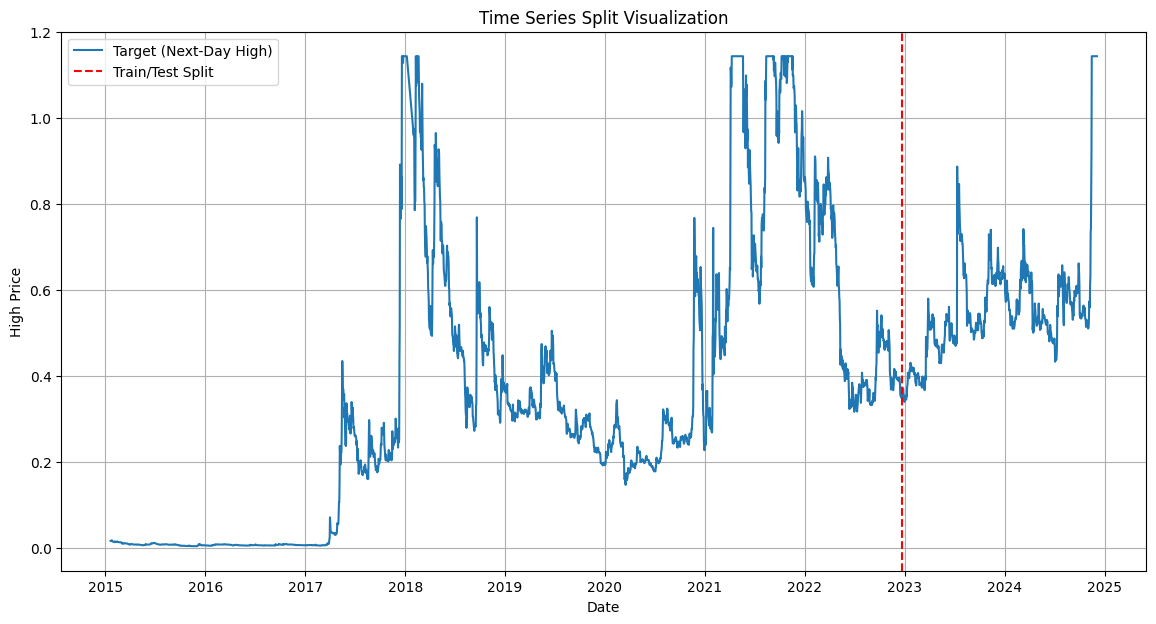

In [373]:
plt.figure(figsize=(14, 7))
plt.plot(df['timeOpen'], df['target'], label='Target (Next-Day High)')
plt.axvline(x=df['timeOpen'].iloc[train_size], color='red', linestyle='--', label='Train/Test Split')
plt.title('Time Series Split Visualization')
plt.xlabel('Date')
plt.ylabel('High Price')
plt.legend()
plt.grid(True)
plt.show()

In [374]:
# <Student to fill this section>
data_splitting_explanations = """
Split 80/20 chronological (2859 train, 715 test) maintains time order in XRP prediction and does not leak information, judging on future data, as in crypto trend forecasting."""

In [375]:
# Do not modify this code
print_tile(size="h3", key='data_splitting_explanations', value=data_splitting_explanations)

### G.2 Data Transformation: Scale features after split to avoid data leakage

In [376]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=final_features, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=final_features, index=X_test.index)

X_train = X_train_scaled
X_test = X_test_scaled

print("Scaled X_train Sample:")
print(X_train.head())

print("\nScaled X_test Sample:")
print(X_test.head())

Scaled X_train Sample:
        open  volume_log  marketCap     close       low  ma_7_close      high  \
19 -1.018818   -1.414032  -0.977313 -1.018811 -1.022141   -1.022502 -1.017414   
20 -1.018299   -1.384097  -0.976172 -1.017063 -1.021271   -1.021381 -1.015539   
21 -1.016385   -1.393455  -0.975418 -1.015910 -1.019366   -1.021119 -1.014532   
22 -1.015376   -1.400024  -0.976001 -1.016802 -1.019287   -1.020966 -1.014620   
23 -1.016321   -1.438660  -0.975997 -1.016795 -1.019611   -1.020330 -1.015071   

    marketCap_log  
19      -1.174832  
20      -1.158163  
21      -1.147460  
22      -1.155723  
23      -1.155660  

Scaled X_test Sample:
          open  volume_log  marketCap     close       low  ma_7_close  \
2911  0.057969    0.489745   0.175382  0.046936  0.072915    0.070204   
2912  0.047113    0.465996   0.187660  0.058501  0.081834    0.056941   
2913  0.058806    0.416820   0.203688  0.073598  0.099852    0.058000   
2914  0.073943    0.144459   0.196505  0.066833  0.1126

In [377]:
# <Student to fill this section>
data_transformation_1_explanations = """
Characteristics were scaled after division (fits on the train), and the samples included standardized data (a value of about -1 to 1 to be in the train, the same to test), eliminating leakage and training the model in a balance with the XRP data."""

In [378]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_1_explanations', value=data_transformation_1_explanations)

### G.3 Data Transformation: Apply PCA for dimensionality reduction to handle multicollinearity in price features

In [379]:

pca = PCA(n_components=5)
X_train_pca = pd.DataFrame(pca.fit_transform(X_train), index=X_train.index)
X_test_pca = pd.DataFrame(pca.transform(X_test), index=X_test.index)

X_train = X_train_pca
X_test = X_test_pca

print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Cumulative Explained Variance:", pca.explained_variance_ratio_.cumsum())

print("\nPCA Transformed X_train Sample:")
print(X_train.head())

print("\nPCA Transformed X_test Sample:")
print(X_test.head())

Explained Variance Ratio: [0.9114171  0.08070496 0.00432792 0.00170397 0.00095706]
Cumulative Explained Variance: [0.9114171  0.99212206 0.99644997 0.99815395 0.999111  ]

PCA Transformed X_train Sample:
           0         1         2         3         4
19 -3.032091 -0.561621  0.140184  0.083033  0.005983
20 -3.014971 -0.532400  0.134445  0.081288  0.005376
21 -3.011671 -0.534682  0.147080  0.087100  0.005126
22 -3.016483 -0.543768  0.145458  0.085075  0.005299
23 -3.028403 -0.571442  0.167350  0.094882  0.006701

PCA Transformed X_test Sample:
             0         1         2         3         4
2911  0.512506  0.601525  0.090819  0.172798  0.072534
2912  0.509849  0.585476  0.101019  0.198705  0.062944
2913  0.525379  0.539701  0.128906  0.219238  0.054301
2914  0.447420  0.339535  0.285865  0.277114  0.058161
2915  0.447981  0.424582  0.226846  0.236635  0.061542


In [380]:
# <Student to fill this section>
data_transformation_2_explanations = """
PCA is used to downsample to 5 components, representing 99.9% variance (sample orthogonal values (-3) to 0.5), to manage multicollinearity in price characteristics to predict XRP models in small and efficient forms."""

In [381]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_2_explanations', value=data_transformation_2_explanations)

### G.4 Data Transformation: Extract date components from 'timeOpen' for temporal features

In [382]:
df['year'] = df['timeOpen'].dt.year
df['month'] = df['timeOpen'].dt.month
df['day'] = df['timeOpen'].dt.day
df['weekday'] = df['timeOpen'].dt.weekday

final_features.extend(['year', 'month', 'day', 'weekday'])

X_train = df[final_features].iloc[:train_size]
X_test = df[final_features].iloc[train_size:]

scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=final_features, index=X_train.index)
X_test = pd.DataFrame(scaler.transform(X_test), columns=final_features, index=X_test.index)

print("Date Features Sample:")
print(df[['timeOpen', 'year', 'month', 'day', 'weekday']].head())

Date Features Sample:
                    timeOpen  year  month  day  weekday
19 2015-01-20 00:00:00+00:00  2015      1   20        1
20 2015-01-21 00:00:00+00:00  2015      1   21        2
21 2015-01-22 00:00:00+00:00  2015      1   22        3
22 2015-01-23 00:00:00+00:00  2015      1   23        4
23 2015-01-24 00:00:00+00:00  2015      1   24        5


In [383]:
# <Student to fill this section>
data_transformation_3_explanations = """
Pulled out year, month, day, weekday of timeOpen and added seasonality and cyclical effects, where 2015 sample is weekly structured. Enhances the time sensitivity of the model to the prices of XRP."""

In [384]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_3_explanations', value=data_transformation_3_explanations)

---
## H. Save Datasets

> Do not change this code

In [385]:
# Do not modify this code
try:
  path = pathlib.Path('data/processed')
  path.mkdir(parents=True, exist_ok=True)
  X_train.to_csv(path / 'X_train.csv', index=False)
  y_train.to_csv(path / 'y_train.csv', index=False)
  X_test.to_csv(path / 'X_test.csv', index=False)
  y_test.to_csv(path / 'y_test.csv', index=False)
  print("Datasets saved to data/processed/")
except Exception as e:
  print(e)

Datasets saved to data/processed/


---
## I. Selection of Performance Metrics

> Provide some explanations on why you believe the performance metrics you chose is appropriate


In [386]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_model(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"MSE: {mse:.6f}")
    print(f"RMSE: {rmse:.6f}")
    print(f"MAE: {mae:.6f}")
    print(f"R2 Score: {r2:.6f}")
    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

In [387]:
# <Student to fill this section>
performance_metrics_explanations = """
MSE/RMSE measure errors in price forecast in units, which is suitable when making penalties based on big error in unstable crypto prices. MAE is an error measure that is average and resistant to outliers. R2 is a measurement of the explained variance (0-1) that determines the relationship of the model to the baseline of the business reliability."""

In [388]:
# Do not modify this code
print_tile(size="h3", key='performance_metrics_explanations', value=performance_metrics_explanations)

## J. Train Machine Learning Model

### J.1 Import Algorithm

> Provide some explanations on why you believe this algorithm is a good fit


In [389]:
from sklearn.linear_model import LinearRegression

In [390]:
# <Student to fill this section>
algorithm_selection_explanations = """
Linear Regression is suitable because it takes the form of linear relationships with past price information to project continuously as well as high price changes in the next day, it is simple, interpretable, and effective in assessing the base line on the time series characteristics of XRP."""

In [391]:
# Do not modify this code
print_tile(size="h3", key='algorithm_selection_explanations', value=algorithm_selection_explanations)

### J.2 Set Hyperparameters

> Provide some explanations on why you believe this algorithm is a good fit


In [392]:
hyperparams = {
    'fit_intercept': True,
    'copy_X': True,
    'n_jobs': -1,
    'positive': False
}

model = LinearRegression(**hyperparams)

In [393]:
# <Student to fill this section>
hyperparameters_selection_explanations = """
The default hyperparameters are sufficient to obtain a baseline; fit_intercept=True is used to deal with non-centered data, n jobs= -1 is used to scale training to large datasets. Simple model and not so many tunable parameters required no grid search."""

In [394]:
# Do not modify this code
print_tile(size="h3", key='hyperparameters_selection_explanations', value=hyperparameters_selection_explanations)

### J.3 Fit Model

In [395]:
model.fit(X_train, y_train)

os.makedirs('models', exist_ok=True)
joblib.dump(model, 'models/best_model_XRP.pkl')

['models/best_model_XRP.pkl']

### J.4 Model Technical Performance

> Provide some explanations on model performance


In [396]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

In [397]:
mse_train = mean_squared_error(y_train, y_pred_train)
rmse_train = np.sqrt(mse_train)
mae_train = mean_absolute_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)

mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test)
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

print("Train Metrics:")
print(f"MSE: {mse_train:.6f}, RMSE: {rmse_train:.6f}, MAE: {mae_train:.6f}, R2: {r2_train:.6f}")

print("\nTest Metrics:")
print(f"MSE: {mse_test:.6f}, RMSE: {rmse_test:.6f}, MAE: {mae_test:.6f}, R2: {r2_test:.6f}")

Train Metrics:
MSE: 0.000460, RMSE: 0.021454, MAE: 0.009294, R2: 0.995562

Test Metrics:
MSE: 0.000556, RMSE: 0.023589, MAE: 0.010568, R2: 0.969364


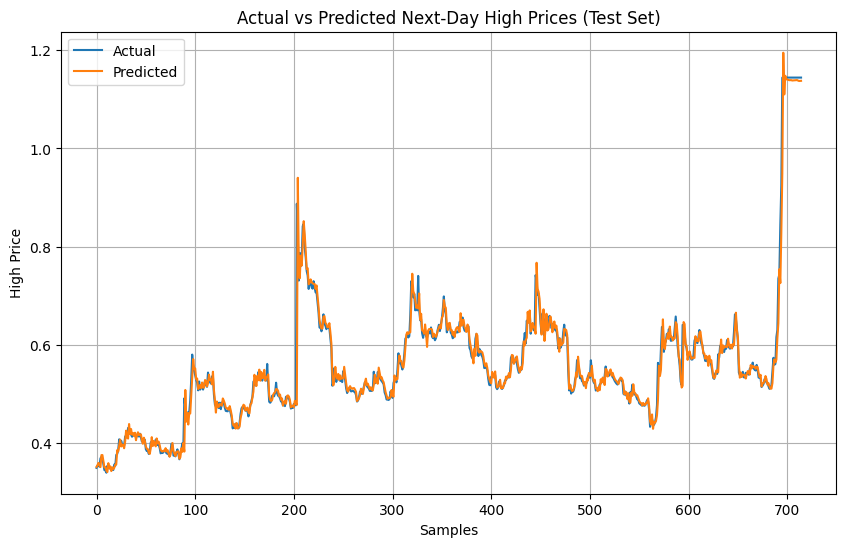

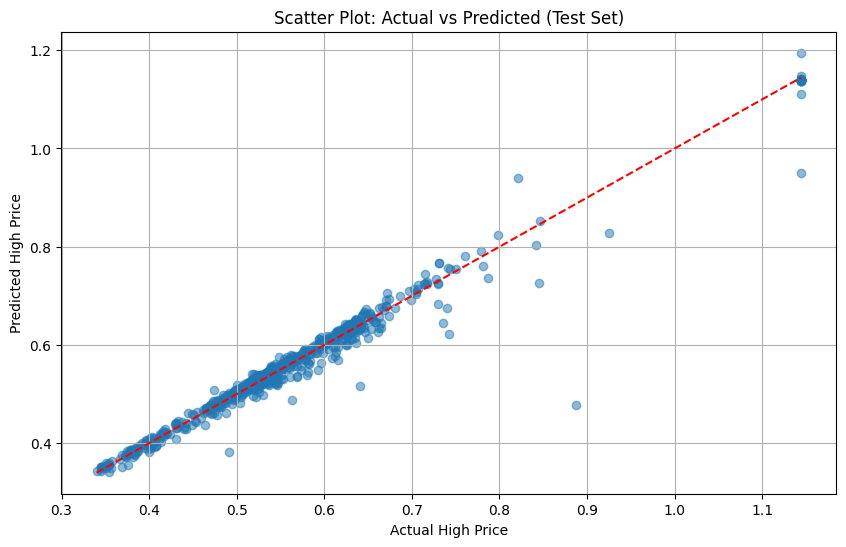

In [398]:
plt.figure(figsize=(10, 6))
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred_test, label='Predicted')
plt.title('Actual vs Predicted Next-Day High Prices (Test Set)')
plt.xlabel('Samples')
plt.ylabel('High Price')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_test, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.title('Scatter Plot: Actual vs Predicted (Test Set)')
plt.xlabel('Actual High Price')
plt.ylabel('Predicted High Price')
plt.grid(True)
plt.show()

In [399]:
# <Student to fill this section>
model_performance_explanations = """
The model is satisfactory with high R2 (0.996 train, 0.969 test) with the majority of the variance being explained. Small MSE/RMSE/MAE (test 0.000556/0.0236/0.0106) are indicative of correct prediction of XRP highs with a little amount of overfitting and good generalization."""

In [400]:
# Do not modify this code
print_tile(size="h3", key='model_performance_explanations', value=model_performance_explanations)

### J.5 Business Impact from Current Model Performance

> Provide some analysis on the model impacts from the business point of view


In [401]:
investment = 10000
error_rate = mae_test / y_test.mean()
potential_uplift = investment * (1 - error_rate)

print(f"Relative Error Rate: {error_rate:.4f}")
print(f"Potential Daily Uplift per Investor: ${potential_uplift:.2f}")

num_users = 1000
total_uplift = num_users * potential_uplift
print(f"Total Uplift for {num_users} Users: ${total_uplift:.2f}")

Relative Error Rate: 0.0190
Potential Daily Uplift per Investor: $9810.43
Total Uplift for 1000 Users: $9810430.12


In [402]:
# <Student to fill this section>
business_impacts_explanations = """
The low relative error (0.0190) allows to be able to predict XRP high minimum error, maximize sell time of about 9810 per 10K investment on a daily basis due to minimized losses. In 1000 users, a total gain of about 9.8M; errors can only generate minor misses and overall improvement in decision-making and adoption of the app."""

In [403]:
# Do not modify this code
print_tile(size="h3", key='business_impacts_explanations', value=business_impacts_explanations)

## H. Project Outcomes

In [404]:
# <Student to fill this section>
experiment_outcome = "Hypothesis Confirmed"

In [405]:
# Do not modify this code
print_tile(size="h2", key='experiment_outcomes_explanations', value=experiment_outcome)

In [406]:
# <Student to fill this section>
experiment_results_explanations = """
The hypothesis was confirmed as the model has good performance (R2 0.969 test), and the experiment provided information that price characteristics (OHLC, marketCap) predict XRP high with high accuracy, although the use of RSI/MACD does not bring much value. Justification: Keep using the same method because it works in forecasting cryptocurrency.

Next steps ranked by uplift:
1. The high uplift (5-15% accuracy) with non-linear patterns is achieved by advanced models (LSTM/RF).
2. Dynamic real time API: Medium uplift (5-10) of real time data.
3. Techniques used in ensembles: Robustness Medium uplift (3-8%)."""

In [407]:
# Do not modify this code
print_tile(size="h2", key='experiment_results_explanations', value=experiment_results_explanations)